LINEAR REGRESSION
-------------------------
Slope: 10.999999999999998
Intercept: -21.999999999999993
Mean Squared Error: 52.79999999999997
R2 Score: 0.9497645211930926

POLYNOMIAL REGRESSION
-------------------------
Mean Squared Error: 2.3922206950827182e-29
R2 Score: 1.0

PREDICTION FOR X = 11
-------------------------
Linear Regression Prediction: 99.0
Polynomial Regression Prediction: 121.00000000000003


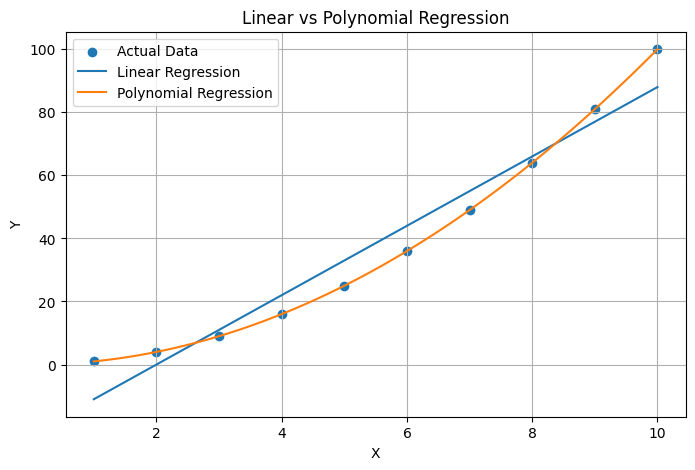

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Dataset
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([1, 4, 9, 16, 25, 36, 49, 64, 81, 100])

# -------------------------------
# Linear Regression
# -------------------------------

linear_model = LinearRegression()
linear_model.fit(X, y)

y_linear = linear_model.predict(X)

# -------------------------------
# Polynomial Regression
# -------------------------------

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

y_poly = poly_model.predict(X_poly)

# -------------------------------
# Performance Comparison
# -------------------------------

linear_mse = mean_squared_error(y, y_linear)
linear_r2 = r2_score(y, y_linear)

poly_mse = mean_squared_error(y, y_poly)
poly_r2 = r2_score(y, y_poly)

print("LINEAR REGRESSION")
print("-------------------------")
print("Slope:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)
print("Mean Squared Error:", linear_mse)
print("R2 Score:", linear_r2)

print("\nPOLYNOMIAL REGRESSION")
print("-------------------------")
print("Mean Squared Error:", poly_mse)
print("R2 Score:", poly_r2)

# -------------------------------
# Prediction for new value
# -------------------------------

new_value = np.array([[11]])

linear_prediction = linear_model.predict(new_value)

new_value_poly = poly.transform(new_value)
poly_prediction = poly_model.predict(new_value_poly)

print("\nPREDICTION FOR X = 11")
print("-------------------------")
print("Linear Regression Prediction:", linear_prediction[0])
print("Polynomial Regression Prediction:", poly_prediction[0])

# -------------------------------
# Plot Comparison
# -------------------------------

X_plot = np.linspace(1, 10, 100).reshape(-1, 1)

linear_plot = linear_model.predict(X_plot)

poly_plot = poly_model.predict(poly.transform(X_plot))

plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Actual Data")
plt.plot(X_plot, linear_plot, label="Linear Regression")
plt.plot(X_plot, poly_plot, label="Polynomial Regression")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.grid(True)

plt.show()